In [36]:
import pandas as pd
df=pd.read_csv('../EDA/cleaned_data_ro.csv')

In [37]:
df.isnull().sum()

price                     0
price_per_sqft            0
super_built_up_area    7025
carpet_area            1832
builtup_area           6329
facing                 2172
ownership                32
bedrooms                 70
bathrooms                71
balcony                  69
floor                   101
furnish_type            873
prop_type                39
city                      0
luxury_score              0
Others                    0
Servant Room              0
Study Room                0
Pooja Room                0
Store Room                0
ageing                   32
location_area             0
dtype: int64

#### carpet area

<Axes: xlabel='carpet_area', ylabel='super_built_up_area'>

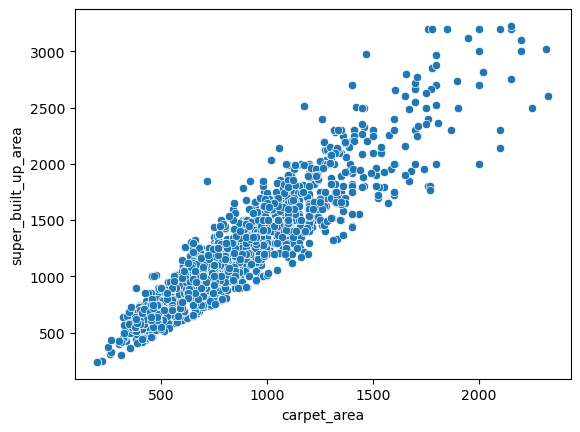

In [38]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.scatterplot(x=df['carpet_area'],y=df['super_built_up_area'])

<Axes: xlabel='carpet_area', ylabel='builtup_area'>

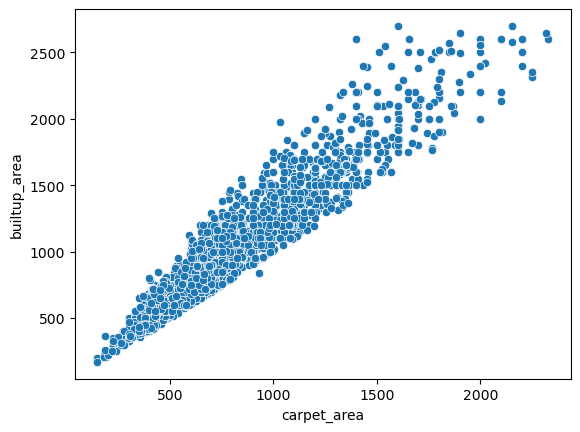

In [39]:
sns.scatterplot(x=df['carpet_area'],y=df['builtup_area'])

In [40]:
df.shape

(9423, 22)

In [41]:
present = df[~((df['super_built_up_area'].isnull()) & (df['builtup_area'].isnull()) & (df['carpet_area'].isnull()))]
present.shape

(8579, 22)

In [42]:
present.isnull().sum()

price                     0
price_per_sqft            0
super_built_up_area    6181
carpet_area             988
builtup_area           5485
facing                 1760
ownership                 1
bedrooms                  1
bathrooms                 2
balcony                   0
floor                    24
furnish_type            577
prop_type                 1
city                      0
luxury_score              0
Others                    0
Servant Room              0
Study Room                0
Pooja Room                0
Store Room                0
ageing                    1
location_area             0
dtype: int64

In [43]:
print("Super to carpet ratio->",(present['super_built_up_area']/present['carpet_area']).mean())

Super to carpet ratio-> 1.4489821185820804


In [ ]:
print("Built to carpet ratio->",(present['builtup_area']/present['carpet_area']).mean())

Built to carpet ratio-> 1.3081429298177334


In [45]:
#both present carpet null
sbb_df = df[~(df['super_built_up_area'].isnull()) & ~(df['builtup_area'].isnull()) & (df['carpet_area'].isnull())]

In [46]:
sbb_df.shape

(62, 22)

In [47]:
sbb_df['carpet_area'].fillna(round(((sbb_df['super_built_up_area']/1.448+(sbb_df['builtup_area']/1.308))/2),2),inplace=True)

C:\Users\91892\AppData\Local\Temp\ipykernel_2072\80976004.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbb_df['carpet_area'].fillna(round(((sbb_df['super_built_up_area']/1.448+(sbb_df['builtup_area']/1.308))/2),2),inplace=True)


In [48]:
df.update(sbb_df)

In [49]:
df.isnull().sum()

price                     0
price_per_sqft            0
super_built_up_area    7025
carpet_area            1770
builtup_area           6329
facing                 2172
ownership                32
bedrooms                 70
bathrooms                71
balcony                  69
floor                   101
furnish_type            873
prop_type                39
city                      0
luxury_score              0
Others                    0
Servant Room              0
Study Room                0
Pooja Room                0
Store Room                0
ageing                   32
location_area             0
dtype: int64

In [50]:
#sb present and both b and c is null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['builtup_area'].isnull()) & (df['carpet_area'].isnull())]

In [51]:
sb_df.shape

(322, 22)

In [52]:
sb_df['carpet_area'].fillna(round((sb_df['super_built_up_area']/1.448),2),inplace=True)

C:\Users\91892\AppData\Local\Temp\ipykernel_2072\533066169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['carpet_area'].fillna(round((sb_df['super_built_up_area']/1.448),2),inplace=True)


In [53]:
df.update(sb_df)

In [54]:
df.isnull().sum()

price                     0
price_per_sqft            0
super_built_up_area    7025
carpet_area            1448
builtup_area           6329
facing                 2172
ownership                32
bedrooms                 70
bathrooms                71
balcony                  69
floor                   101
furnish_type            873
prop_type                39
city                      0
luxury_score              0
Others                    0
Servant Room              0
Study Room                0
Pooja Room                0
Store Room                0
ageing                   32
location_area             0
dtype: int64

In [55]:
#b present and both sb and c is null
b_df = df[(df['super_built_up_area'].isnull()) & ~(df['builtup_area'].isnull()) & (df['carpet_area'].isnull())]
b_df.shape

(604, 22)

In [56]:
b_df['carpet_area'].fillna(round(b_df['builtup_area']/1.308,2),inplace=True)

C:\Users\91892\AppData\Local\Temp\ipykernel_2072\4207185270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b_df['carpet_area'].fillna(round(b_df['builtup_area']/1.308,2),inplace=True)


In [57]:
b_df.head()

,price,price_per_sqft,super_built_up_area,carpet_area,builtup_area,facing,ownership,bedrooms,bathrooms,balcony,...,prop_type,city,luxury_score,Others,Servant Room,Study Room,Pooja Room,Store Room,ageing,location_area
221,8900000.0,23237.0,NaN,292.81,383.0,East,Freehold,1.0,2.0,0.0,...,Flat,Mumbai,84,0,0,0,0,0,New,Malad
229,4600000.0,6855.0,NaN,513.00,671.0,North-East,Freehold,1.0,1.0,0.0,...,Flat,Navi Mumbai,122,0,0,0,1,0,New,Ulwe
257,29000000.0,29441.0,NaN,753.06,985.0,North,Freehold,2.0,2.0,0.0,...,Flat,Mumbai,104,0,0,0,0,0,New,Santacruz
258,28000000.0,28865.0,NaN,741.59,970.0,North,Freehold,2.0,2.0,0.0,...,Flat,Mumbai,94,0,0,0,0,0,Relatively Old,Santacruz
330,9300000.0,15500.0,NaN,458.72,600.0,North-West,Freehold,1.0,2.0,2.0,...,Flat,Mumbai,192,0,0,0,0,0,Relatively Old,Mumbai


In [58]:
df.update(b_df)

In [59]:
df = df[~((df['super_built_up_area'].isnull()) & (df['builtup_area'].isnull()) & (df['carpet_area'].isnull()))]
df.drop(columns=['super_built_up_area','builtup_area'],inplace=True)

In [60]:
df.isnull().sum()

price                0
price_per_sqft       0
carpet_area          0
facing            1760
ownership            1
bedrooms             1
bathrooms            2
balcony              0
floor               24
furnish_type       577
prop_type            1
city                 0
luxury_score         0
Others               0
Servant Room         0
Study Room           0
Pooja Room           0
Store Room           0
ageing               1
location_area        0
dtype: int64

<Axes: xlabel='carpet_area', ylabel='price'>

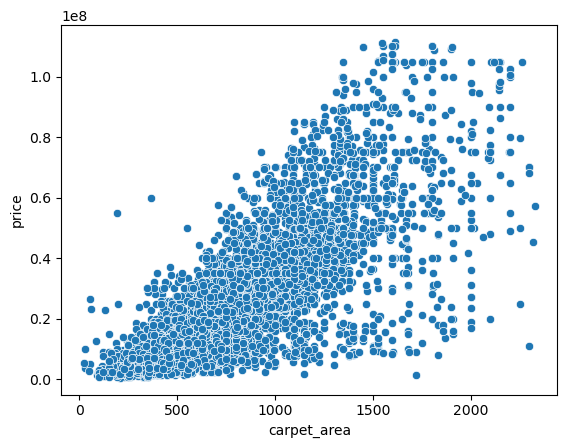

In [61]:
sns.scatterplot(x=df['carpet_area'],y=df['price'])

#### floornum

<Axes: xlabel='floor', ylabel='Count'>

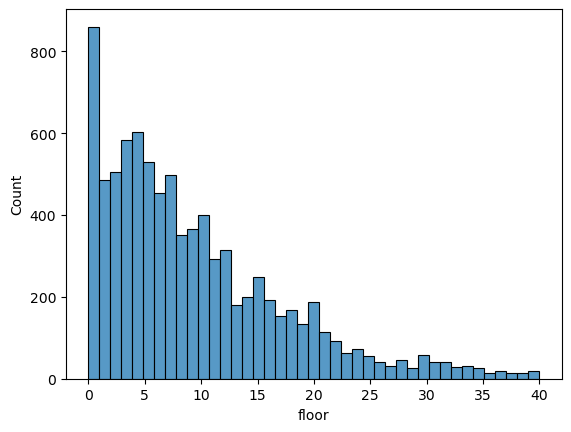

In [62]:
sns.histplot(x=df['floor'])

In [63]:
print(df['floor'].median())
print(df['floor'].mean())

7.0
9.209818819403857


In [64]:
df['floor'].fillna(7,inplace=True)
df.isna().sum()

price                0
price_per_sqft       0
carpet_area          0
facing            1760
ownership            1
bedrooms             1
bathrooms            2
balcony              0
floor                0
furnish_type       577
prop_type            1
city                 0
luxury_score         0
Others               0
Servant Room         0
Study Room           0
Pooja Room           0
Store Room           0
ageing               1
location_area        0
dtype: int64

In [65]:
1756/df.shape[0]
#simple imputer with constant value filled as "Missing" and column to represent na value

0.20468586082293974

#### furnish type

In [66]:
import numpy as np
def mode_based_imputation(row):
    if row['furnish_type'] is np.nan:
        mode_value = df[(df['location_area'] == row['location_area']) & (df['prop_type'] == row['prop_type'])]['furnish_type'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['furnish_type']

In [67]:
df['furnish_type'] = df.apply(mode_based_imputation,axis=1)

In [68]:
df.isna().sum()

price                0
price_per_sqft       0
carpet_area          0
facing            1760
ownership            1
bedrooms             1
bathrooms            2
balcony              0
floor                0
furnish_type         2
prop_type            1
city                 0
luxury_score         0
Others               0
Servant Room         0
Study Room           0
Pooja Room           0
Store Room           0
ageing               1
location_area        0
dtype: int64

In [69]:
# Drop rows where ownership, bedrooms, bathrooms, prop_type, or ageing are missing
df = df.dropna(subset=['ownership', 'bedrooms', 'bathrooms', 'prop_type', 'ageing','furnish_type'])

In [70]:
df.to_csv('imputed_data.csv',index=False)